In [1]:
import sys

!{sys.executable} -m pip uninstall -y opencv-python opencv-contrib-python
!{sys.executable} -m pip install opencv-python-headless

Found existing installation: opencv-python 4.10.0.84
Uninstalling opencv-python-4.10.0.84:
  Successfully uninstalled opencv-python-4.10.0.84


In [5]:
!pip install opencv-python

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.8/73.8 MB 36.4 MB/s eta 0:00:00:00:0100:01


In [1]:
import shutil
from pathlib import Path

# Directory variables for Project, Data and Extracted Validation Set paths
PROJECT_ROOT = Path.cwd().resolve()
DATA_DIR = PROJECT_ROOT / "data" / "avdeepfake1mpp"
EXTRACTED_VAL = DATA_DIR / "extracted" / "val" / "val"

# Gathering videos via recursive glob
videos = sorted(EXTRACTED_VAL.rglob("*.mp4"))

# Printing the number of videos and the first 10 videos
print(f"Number of videos: {len(videos)}")
print(f"First 10 videos")
for v in videos[:10]:
    print(v)

# Printing the storage used
total, used, free = shutil.disk_usage(PROJECT_ROOT)
print(f"\nTotal: {total / 1024**3:.2f} GB")
print(f"Used:  {used / 1024**3:.2f} GB")
print(f"Free:  {free / 1024**3:.2f} GB")


Number of videos: 77326
First 10 videos
/home/jovyan/MSC_PROJECT/data/avdeepfake1mpp/extracted/val/val/lrs3/1Hok1iGFNSk/00004/fake_video_fake_audio.mp4
/home/jovyan/MSC_PROJECT/data/avdeepfake1mpp/extracted/val/val/lrs3/1Hok1iGFNSk/00004/fake_video_real_audio.mp4
/home/jovyan/MSC_PROJECT/data/avdeepfake1mpp/extracted/val/val/lrs3/1Hok1iGFNSk/00004/real.mp4
/home/jovyan/MSC_PROJECT/data/avdeepfake1mpp/extracted/val/val/lrs3/1Hok1iGFNSk/00004/real_video_fake_audio.mp4
/home/jovyan/MSC_PROJECT/data/avdeepfake1mpp/extracted/val/val/lrs3/2YPHJdq5QWM/00001/00001_p1.mp4
/home/jovyan/MSC_PROJECT/data/avdeepfake1mpp/extracted/val/val/lrs3/2YPHJdq5QWM/00001/00001_p2.mp4
/home/jovyan/MSC_PROJECT/data/avdeepfake1mpp/extracted/val/val/lrs3/2YPHJdq5QWM/00001/00001_p3.mp4
/home/jovyan/MSC_PROJECT/data/avdeepfake1mpp/extracted/val/val/lrs3/2YPHJdq5QWM/00002/00002_p1.mp4
/home/jovyan/MSC_PROJECT/data/avdeepfake1mpp/extracted/val/val/lrs3/2YPHJdq5QWM/00002/00002_p2.mp4
/home/jovyan/MSC_PROJECT/data/avde

FPS: 25.0
Frame Count: 453.0
Width: 224.0
Height: 224.0
First frame loaded: True
Frame shape: (224, 224, 3)


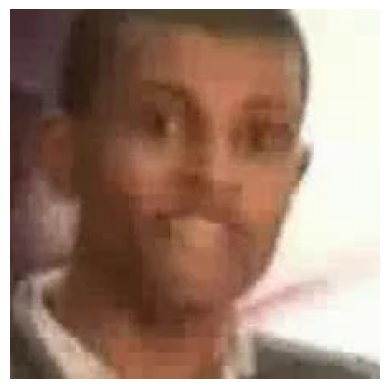

In [2]:
import cv2
import matplotlib.pyplot as plt

sample_vid = videos[0]

capture = cv2.VideoCapture(str(sample_vid))

if not capture.isOpened():
    print("Error: Video has not been opened")
print(f"FPS: {capture.get(cv2.CAP_PROP_FPS)}")
print(f"Frame Count: {capture.get(cv2.CAP_PROP_FRAME_COUNT)}")
print(f"Width: {capture.get(cv2.CAP_PROP_FRAME_WIDTH)}")
print(f"Height: {capture.get(cv2.CAP_PROP_FRAME_HEIGHT)}")


ret, frame = capture.read()
capture.release()

print(f"First frame loaded: {ret}")
if ret:
    print(f"Frame shape: {frame.shape}")

    frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

    plt.imshow(frame_rgb)
    plt.axis("off")
    plt.show()

   

In [ ]:
import pandas as pd
import tqdm

def frame_check(videos):
    rows = []
    failed_count = 0
    
    for video in tqdm.tqdm(videos, desc="Checking videos", unit="video"):
        capture = cv2.VideoCapture(str(video))
    
        opened = capture.isOpened()
        
        fps = capture.get(cv2.CAP_PROP_FPS) if opened else None
        frame_count = capture.get(cv2.CAP_PROP_FRAME_COUNT) if opened else None
        width = capture.get(cv2.CAP_PROP_FRAME_WIDTH) if opened else None
        height = capture.get(cv2.CAP_PROP_FRAME_HEIGHT) if opened else None
    
        ret, frame = capture.read() if opened else (False, None)
        capture.release()
        
        rows.append({
            "path": str(video),
            "opened": opened,
            "fps": fps,
            "frame_count": frame_count,
            "width": width,
            "height": height,
            "first_frame_loaded": ret,    
        })

        if not ret:
            failed_count += 1
            tqdm.write(
                f"Frame not loaded: {path} "
                f"(failed count: {failed_count})"
            )

    if failed_count == 0:
        print("All first frames for all videos were successfully loaded")
        
    df = pd.DataFrame(rows)

    return df 
    
frame_check(videos)

Checking videos:  93%|█████████▎| 71867/77326 [11:46<00:57, 94.82video/s] 